# Coupon Targeting — ลด Coupon Waste

**วัตถุประสงค์:** ระบุกลุ่มเป้าหมายที่ควรได้รับ coupon เพื่อลดความสิ้นเปลือง

1. **Coupon ROI Score** = `Churn_Prob × CashbackAmount`
2. **Precision-Recall Curve** — หา optimal threshold ตาม budget

**Prerequisite:** รัน `prediction_stacking.ipynb` ก่อน → ได้ไฟล์ `predictions.csv`

## 1. Import & Load Predictions

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import precision_recall_curve, average_precision_score

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/csv', exist_ok=True)

sns.set_theme(style='whitegrid')

df = pd.read_csv('outputs/csv/predictions.csv')
print(f'Loaded: {df.shape}')
display(df.head())

Loaded: (5630, 16)


,CustomerID,Churn,CashbackAmount,Tenure,OrderCount,DaySinceLastOrder,Complain,SatisfactionScore,CouponUsed,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus,Churn_Prob,Churn_Pred
0,50001,1,160,4.0,1.0,5.0,1,2,1.0,Mobile Phone,Debit Card,Female,Laptop & Accessory,Single,0.9816,1
1,50002,1,121,9.0,1.0,0.0,1,3,0.0,Phone,UPI,Male,Mobile,Single,0.9685,1
2,50003,1,120,9.0,1.0,3.0,1,3,0.0,Phone,Debit Card,Male,Mobile,Single,0.9791,1
3,50004,1,134,0.0,1.0,3.0,0,5,0.0,Phone,Debit Card,Male,Laptop & Accessory,Single,0.9674,1
4,50005,1,130,0.0,1.0,3.0,0,5,1.0,Phone,CC,Male,Mobile,Single,0.9803,1


## 2. EDA — Coupon Usage & Patterns

วิเคราะห์ว่าลูกค้าที่ใช้ Coupon มากหรือน้อยมีพฤติกรรม Churn อย่างไร และปัจจัยใดที่เกี่ยวข้อง

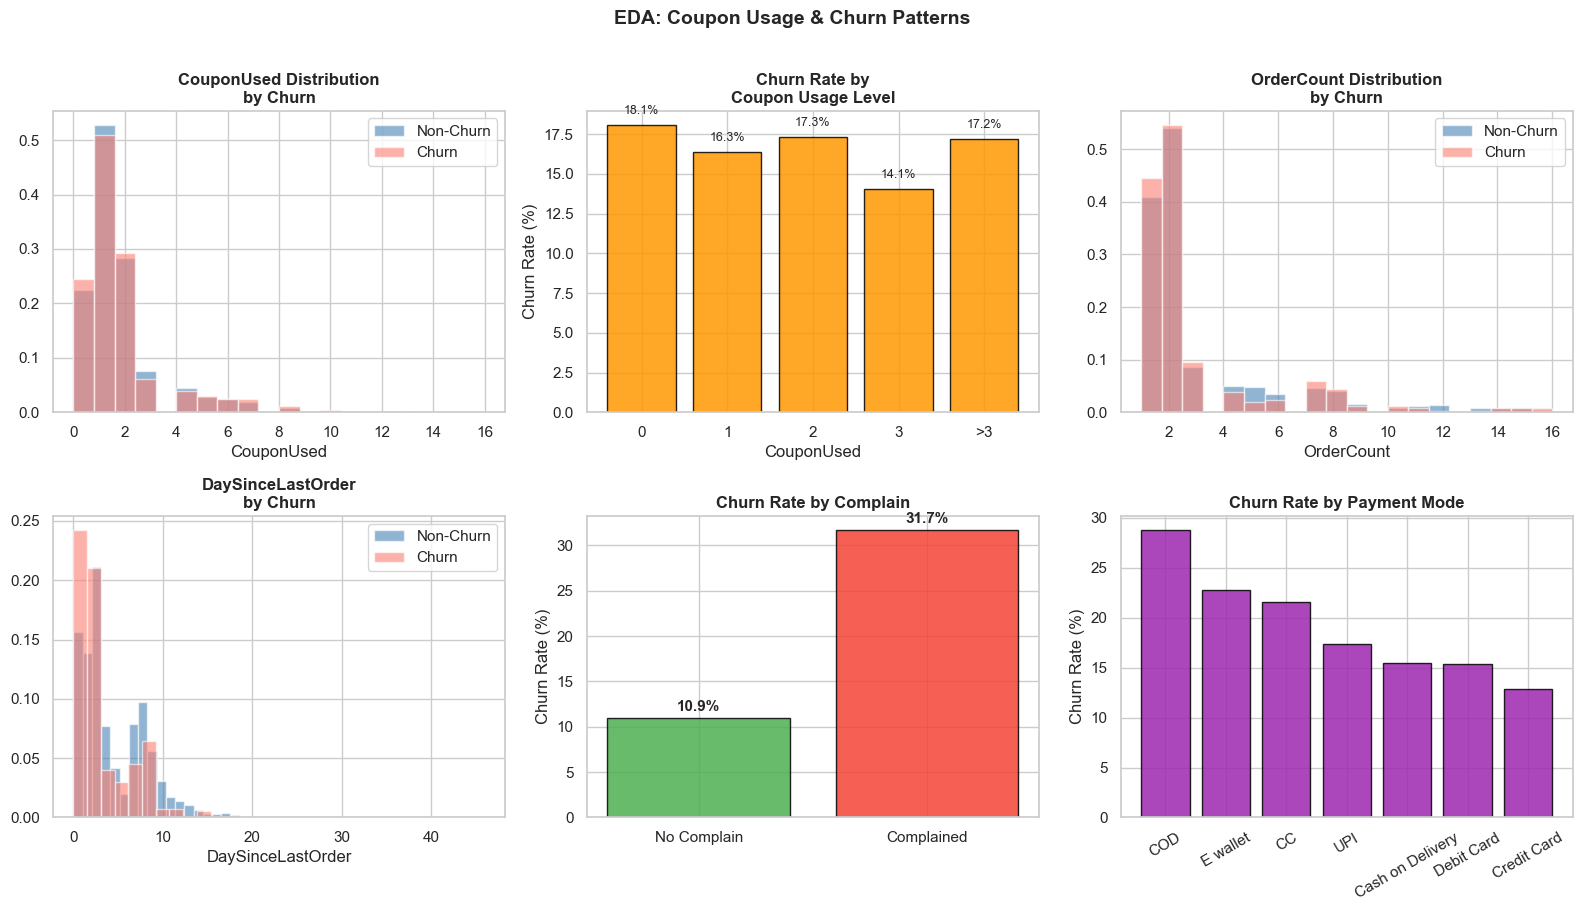

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. CouponUsed distribution by Churn
for val, label, color in [(0,'Non-Churn','steelblue'),(1,'Churn','salmon')]:
    sub = df[df['Churn']==val]['CouponUsed']
    axes[0,0].hist(sub, bins=20, alpha=0.6, label=label, color=color, density=True)
axes[0,0].set_title('CouponUsed Distribution\nby Churn', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('CouponUsed'); axes[0,0].legend()

# 2. Churn rate by CouponUsed bucket
df['Coupon_Group'] = pd.cut(df['CouponUsed'], bins=[-1,0,1,2,3,20],
                              labels=['0','1','2','3','>3'])
churn_by_coupon = df.groupby('Coupon_Group')['Churn'].mean() * 100
bars = axes[0,1].bar(churn_by_coupon.index, churn_by_coupon.values,
                      color='#FF9800', edgecolor='black', alpha=0.85)
for bar in bars:
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
axes[0,1].set_title('Churn Rate by\nCoupon Usage Level', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('CouponUsed'); axes[0,1].set_ylabel('Churn Rate (%)')

# 3. OrderCount distribution by Churn
for val, label, color in [(0,'Non-Churn','steelblue'),(1,'Churn','salmon')]:
    sub = df[df['Churn']==val]['OrderCount']
    axes[0,2].hist(sub, bins=20, alpha=0.6, label=label, color=color, density=True)
axes[0,2].set_title('OrderCount Distribution\nby Churn', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('OrderCount'); axes[0,2].legend()

# 4. DaySinceLastOrder by Churn
for val, label, color in [(0,'Non-Churn','steelblue'),(1,'Churn','salmon')]:
    sub = df[df['Churn']==val]['DaySinceLastOrder']
    axes[1,0].hist(sub, bins=30, alpha=0.6, label=label, color=color, density=True)
axes[1,0].set_title('DaySinceLastOrder\nby Churn', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('DaySinceLastOrder'); axes[1,0].legend()

# 5. Complain vs Churn rate
complain_churn = df.groupby('Complain')['Churn'].mean() * 100
axes[1,1].bar(['No Complain','Complained'], complain_churn.values,
               color=['#4CAF50','#F44336'], edgecolor='black', alpha=0.85)
for i, val in enumerate(complain_churn.values):
    axes[1,1].text(i, val+0.5, f'{val:.1f}%', ha='center', va='bottom',
                   fontsize=11, fontweight='bold')
axes[1,1].set_title('Churn Rate by Complain', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Churn Rate (%)')

# 6. PreferredPaymentMode vs Churn
pay_churn = df.groupby('PreferredPaymentMode')['Churn'].mean().sort_values(ascending=False) * 100
axes[1,2].bar(pay_churn.index, pay_churn.values,
               color='#9C27B0', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Churn Rate by Payment Mode', fontsize=12, fontweight='bold')
axes[1,2].set_ylabel('Churn Rate (%)'); axes[1,2].tick_params(axis='x', rotation=30)

plt.suptitle('EDA: Coupon Usage & Churn Patterns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

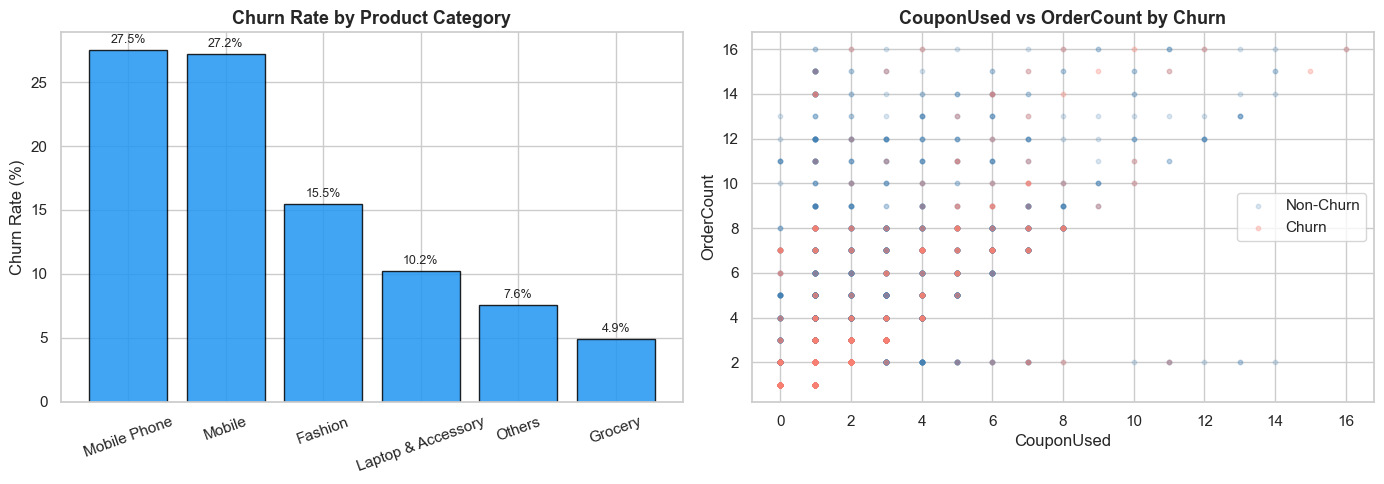

Churn rate by Preferred Category:
PreferedOrderCat
Mobile Phone          27.537372
Mobile                27.194067
Fashion               15.496368
Laptop & Accessory    10.243902
Others                 7.575758
Grocery                4.878049


In [3]:
# Preferred product category vs Churn rate — สำคัญสำหรับการเลือก coupon type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_churn = df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False) * 100
bars = axes[0].bar(cat_churn.index, cat_churn.values,
                    color='#2196F3', edgecolor='black', alpha=0.85)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Churn Rate by Product Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)'); axes[0].tick_params(axis='x', rotation=20)

# Coupon used vs OrderCount — relationship
axes[1].scatter(df[df['Churn']==0]['CouponUsed'], df[df['Churn']==0]['OrderCount'],
                alpha=0.2, s=10, color='steelblue', label='Non-Churn')
axes[1].scatter(df[df['Churn']==1]['CouponUsed'], df[df['Churn']==1]['OrderCount'],
                alpha=0.3, s=10, color='salmon', label='Churn')
axes[1].set_xlabel('CouponUsed'); axes[1].set_ylabel('OrderCount')
axes[1].set_title('CouponUsed vs OrderCount by Churn', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Churn rate by Preferred Category:')
print(cat_churn.to_string())

## 3. Value-Risk Quadrant (กรอง LET GO ออก)

In [4]:
CHURN_THRESHOLD = 0.35
VALUE_MEDIAN    = df['CashbackAmount'].median()

# ใช้ label ที่ไม่มี \n เพื่อให้ CSV export ถูกต้อง
quad_labels = {
    'PROTECT (VIP Loyalty)'       : '#2196F3',
    'RESCUE (Win-back + Loyalty)' : '#F44336',
    'MAINTAIN (Basic Perks)'      : '#4CAF50',
    'LET GO (ไม่ลงทุน)'           : '#9E9E9E',
}
quad_colors = quad_labels  # alias for plotting

def assign_quadrant(row):
    high_risk  = row['Churn_Prob']     >= CHURN_THRESHOLD
    high_value = row['CashbackAmount'] >= VALUE_MEDIAN
    if     high_value and not high_risk: return 'PROTECT (VIP Loyalty)'
    elif   high_value and     high_risk: return 'RESCUE (Win-back + Loyalty)'
    elif not high_value and not high_risk: return 'MAINTAIN (Basic Perks)'
    else:                                  return 'LET GO (ไม่ลงทุน)'

df['Quadrant']        = df.apply(assign_quadrant, axis=1)
df['Coupon_Eligible'] = df['Quadrant'] != 'LET GO (ไม่ลงทุน)'


print(f'Coupon eligible  : {df["Coupon_Eligible"].sum():,}  ({df["Coupon_Eligible"].mean():.1%})')
print(f'LET GO (excluded): {(~df["Coupon_Eligible"]).sum():,}  ({(~df["Coupon_Eligible"]).mean():.1%})')

Coupon eligible  : 4,965  (88.2%)
LET GO (excluded): 665  (11.8%)


## 4. Coupon ROI Score

In [5]:
df['Coupon_ROI_Score'] = df['Churn_Prob'] * df['CashbackAmount']
s_min, s_max = df['Coupon_ROI_Score'].min(), df['Coupon_ROI_Score'].max()
df['ROI_Score'] = ((df['Coupon_ROI_Score'] - s_min) / (s_max - s_min) * 100).round(2)

coupon_df = (
    df[df['Coupon_Eligible']]
    [['CustomerID','Churn_Prob','ROI_Score','CashbackAmount','Quadrant','Churn']]
    .rename(columns={'Quadrant':'Value_Risk','Churn':'Actual_Churn'})
    .sort_values('ROI_Score', ascending=False)
    .reset_index(drop=True)
)
coupon_df.index += 1
coupon_df.index.name = 'Rank'

print('Top 20 Highest-ROI Customers:')
display(coupon_df.head(20).style
        .background_gradient(subset=['ROI_Score'],      cmap='YlOrRd')
        .background_gradient(subset=['Churn_Prob'],     cmap='Reds')
        .background_gradient(subset=['CashbackAmount'], cmap='Greens')
        .format({'Churn_Prob':'{:.3f}','ROI_Score':'{:.1f}','CashbackAmount':'{:.0f}'}))

Top 20 Highest-ROI Customers:


,CustomerID,Churn_Prob,ROI_Score,CashbackAmount,Value_Risk,Actual_Churn
Rank,,,,,,
1,53440,0.969,100.0,323,RESCUE (Win-back + Loyalty),1
2,54729,0.952,98.5,324,RESCUE (Win-back + Loyalty),1
3,53604,0.979,97.8,313,RESCUE (Win-back + Loyalty),1
4,55074,0.978,97.7,313,RESCUE (Win-back + Loyalty),1
5,50625,0.986,93.8,298,RESCUE (Win-back + Loyalty),1
6,54756,0.926,93.7,317,RESCUE (Win-back + Loyalty),1
7,51914,0.977,93.2,299,RESCUE (Win-back + Loyalty),1
8,53286,0.921,93.2,317,RESCUE (Win-back + Loyalty),1
9,52095,0.979,93.2,298,RESCUE (Win-back + Loyalty),1


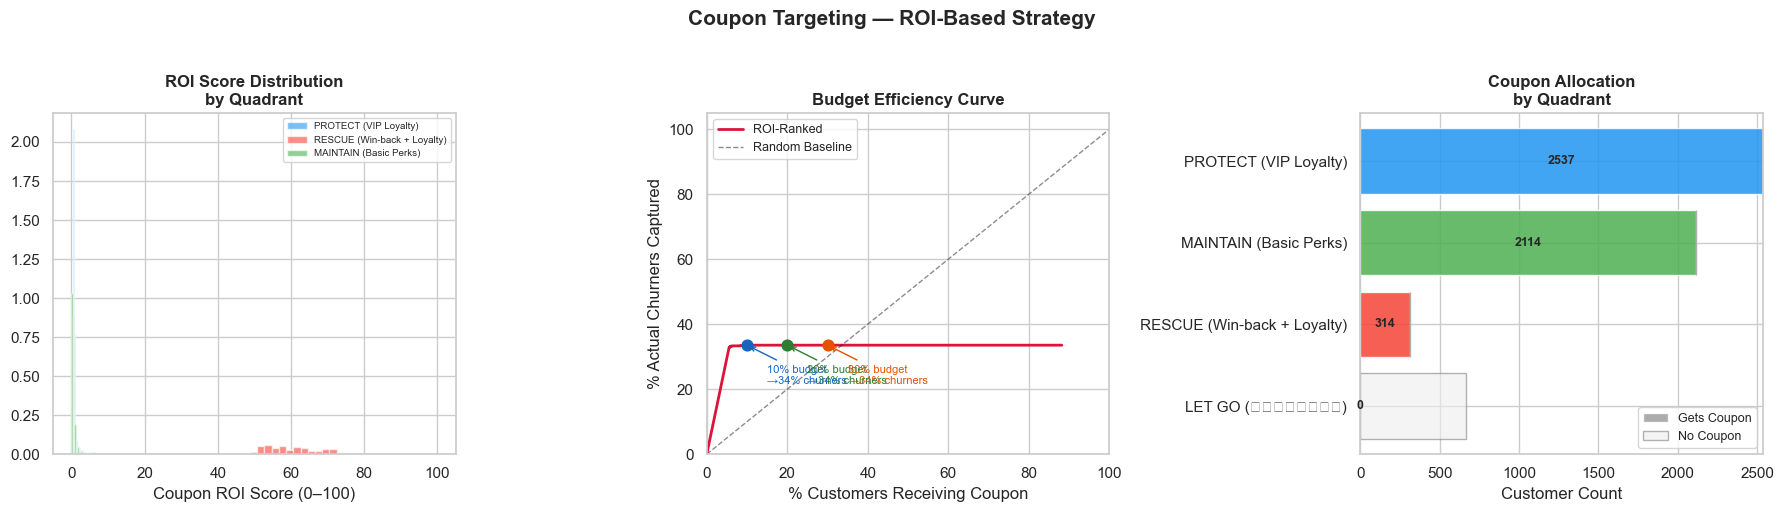

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROI Score Distribution
for q, color in quad_colors.items():
    if q == 'LET GO (ไม่ลงทุน)': continue
    axes[0].hist(df[df['Quadrant']==q]['ROI_Score'], bins=40,
                 alpha=0.6, label=q, color=color, density=True)
axes[0].set_xlabel('Coupon ROI Score (0–100)')
axes[0].set_title('ROI Score Distribution\nby Quadrant', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=7)

# Budget Efficiency Curve
df_s = df[df['Coupon_Eligible']].sort_values('ROI_Score', ascending=False).reset_index(drop=True)
pct_sent     = (np.arange(1, len(df_s)+1)) / len(df) * 100
pct_captured = df_s['Churn'].cumsum() / df['Churn'].sum() * 100

axes[1].plot(pct_sent, pct_captured, color='crimson', lw=2, label='ROI-Ranked')
axes[1].plot([0,100],[0,100], 'k--', lw=1, alpha=0.5, label='Random Baseline')
for budget, color in zip([10,20,30],['#1565C0','#2E7D32','#E65100']):
    idx      = min(np.searchsorted(pct_sent, budget), len(pct_captured)-1)
    captured = pct_captured.iloc[idx]
    axes[1].annotate(f'{budget}% budget\n→{captured:.0f}% churners',
                     xy=(budget, captured), xytext=(budget+5, captured-12),
                     arrowprops=dict(arrowstyle='->', color=color), fontsize=8, color=color)
    axes[1].scatter([budget],[captured], color=color, s=60, zorder=5)
axes[1].set_xlabel('% Customers Receiving Coupon')
axes[1].set_ylabel('% Actual Churners Captured')
axes[1].set_title('Budget Efficiency Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_xlim(0,100); axes[1].set_ylim(0,105)

# Coupon Allocation Breakdown
elig = df.groupby('Quadrant')['Coupon_Eligible'].agg(['sum','count'])
elig.columns = ['Eligible','Total']
elig['Not'] = elig['Total'] - elig['Eligible']
elig = elig.sort_values('Eligible', ascending=True)
labels = [q for q in elig.index]
bars_e = axes[2].barh(labels, elig['Eligible'],
                       color=[quad_colors[q] for q in elig.index], alpha=0.85, label='Gets Coupon')
axes[2].barh(labels, elig['Not'], left=elig['Eligible'],
              color='#EEEEEE', edgecolor='gray', alpha=0.6, label='No Coupon')
for bar, val in zip(bars_e, elig['Eligible']):
    axes[2].text(bar.get_width()/2, bar.get_y()+bar.get_height()/2,
                 str(int(val)), ha='center', va='center', fontsize=9, fontweight='bold')
axes[2].set_xlabel('Customer Count')
axes[2].set_title('Coupon Allocation\nby Quadrant', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Coupon Targeting — ROI-Based Strategy', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/coupon_targeting.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Precision-Recall Curve — Optimal Threshold ตาม Budget

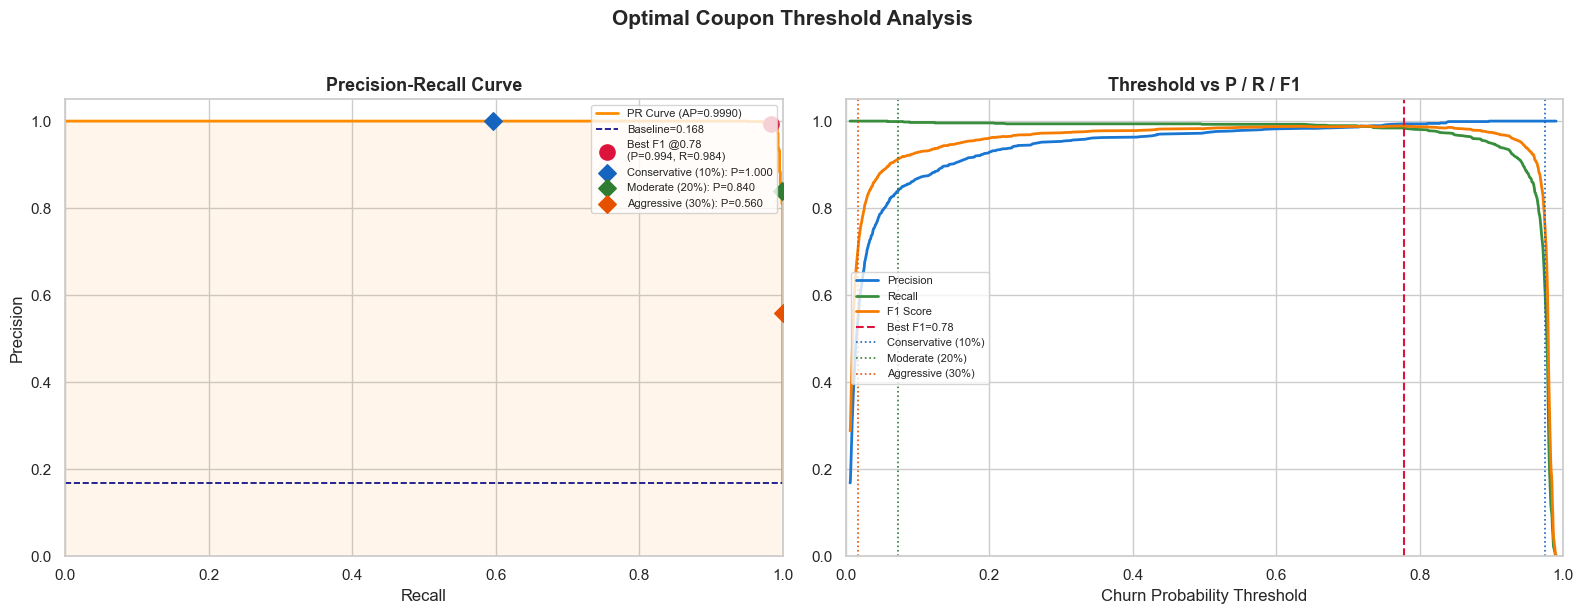

  Budget Scenario Analysis
  Scenario                   Threshold  Precision     Recall   Coupons Sent
-----------------------------------------------------------------
  Conservative (10%)             0.975      1.000      0.596            565
  Moderate (20%)                 0.073      0.840      0.999          1,127
  Aggressive (30%)               0.018      0.560      1.000          1,694
  Best F1 (balanced)             0.777      0.994      0.984            939


In [7]:
precision, recall, pr_thresholds = precision_recall_curve(df['Churn'], df['Churn_Prob'])
ap_score  = average_precision_score(df['Churn'], df['Churn_Prob'])
f1_scores = np.where((precision+recall)==0, 0,
                     2*precision*recall/(precision+recall))
best_idx       = np.argmax(f1_scores[:-1])
best_threshold = pr_thresholds[best_idx]
best_precision = precision[best_idx]
best_recall    = recall[best_idx]

scenarios  = {
    'Conservative (10%)' : np.percentile(df['Churn_Prob'], 90),
    'Moderate (20%)'     : np.percentile(df['Churn_Prob'], 80),
    'Aggressive (30%)'   : np.percentile(df['Churn_Prob'], 70),
}
sc_colors = ['#1565C0','#2E7D32','#E65100']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(recall, precision, color='darkorange', lw=2, label=f'PR Curve (AP={ap_score:.4f})')
ax.axhline(df['Churn'].mean(), color='navy', linestyle='--', lw=1.2,
           label=f'Baseline={df["Churn"].mean():.3f}')
ax.scatter([best_recall],[best_precision], color='crimson', s=120, zorder=5,
           label=f'Best F1 @{best_threshold:.2f}\n(P={best_precision:.3f}, R={best_recall:.3f})')
for (label, thresh), color in zip(scenarios.items(), sc_colors):
    idx = min(np.searchsorted(pr_thresholds, thresh), len(precision)-2)
    ax.scatter([recall[idx]], [precision[idx]], color=color, s=80, marker='D', zorder=4,
               label=f'{label}: P={precision[idx]:.3f}')
ax.fill_between(recall, precision, alpha=0.08, color='darkorange')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper right'); ax.set_xlim(0,1); ax.set_ylim(0,1.05)

ax2 = axes[1]
ax2.plot(pr_thresholds, precision[:-1], color='#1976D2', lw=2, label='Precision')
ax2.plot(pr_thresholds, recall[:-1],    color='#388E3C', lw=2, label='Recall')
ax2.plot(pr_thresholds, f1_scores[:-1], color='#F57C00', lw=2, label='F1 Score')
ax2.axvline(best_threshold, color='crimson', linestyle='--', lw=1.5,
            label=f'Best F1={best_threshold:.2f}')
for (label, thresh), color in zip(scenarios.items(), sc_colors):
    ax2.axvline(thresh, color=color, linestyle=':', lw=1.2, label=label)
ax2.set_xlabel('Churn Probability Threshold')
ax2.set_title('Threshold vs P / R / F1', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8, loc='center left'); ax2.set_xlim(0,1); ax2.set_ylim(0,1.05)

plt.suptitle('Optimal Coupon Threshold Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/precision_recall_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 65)
print('  Budget Scenario Analysis')
print('=' * 65)
print(f'  {"Scenario":<25} {"Threshold":>10} {"Precision":>10} {"Recall":>10} {"Coupons Sent":>14}')
print('-' * 65)
for (label, thresh), color in zip(scenarios.items(), sc_colors):
    idx = min(np.searchsorted(pr_thresholds, thresh), len(precision)-2)
    print(f'  {label:<25} {thresh:>10.3f} {precision[idx]:>10.3f} {recall[idx]:>10.3f} {(df["Churn_Prob"]>=thresh).sum():>14,}')
print(f'  {"Best F1 (balanced)":<25} {best_threshold:>10.3f} {best_precision:>10.3f} {best_recall:>10.3f} {(df["Churn_Prob"]>=best_threshold).sum():>14,}')
print('=' * 65)

## 6. Final Coupon Target List

In [8]:
final_df = (
    df[
        df['Coupon_Eligible'] &
        (df['Churn_Prob'] >= best_threshold)
    ][['CustomerID','Churn_Prob','ROI_Score','CashbackAmount',
       'Tenure','Complain','SatisfactionScore','Quadrant','Churn']]
    .rename(columns={'Quadrant':'Value_Risk','Churn':'Actual_Churn'})
    .sort_values('ROI_Score', ascending=False)
    .reset_index(drop=True)
)
final_df.index += 1
final_df.index.name = 'Coupon_Priority'

print('=' * 65)
print('  FINAL COUPON TARGET LIST')
print('=' * 65)
print(f'  Total customers         : {len(df):,}')
print(f'  After LET GO filter     : {df["Coupon_Eligible"].sum():,}')
print(f'  After threshold filter  : {len(final_df):,}  ({len(final_df)/len(df):.1%})')
print(f'  Coupons saved (waste↓)  : {len(df)-len(final_df):,}  ({(len(df)-len(final_df))/len(df):.1%})')
print(f'  Optimal threshold       : {best_threshold:.3f}')
print('=' * 65)

print('\nBreakdown by Quadrant:')
display(final_df.groupby('Value_Risk').agg(
    Count    =('CustomerID',   'count'),
    Avg_ROI  =('ROI_Score',    'mean'),
    Avg_Prob =('Churn_Prob',   'mean'),
    Precision=('Actual_Churn', 'mean')
).round(3).sort_values('Avg_Prob', ascending=False))

print('\nTop 25 Priority Coupon Recipients:')
display(final_df.head(25).style
        .background_gradient(subset=['ROI_Score'],      cmap='YlOrRd')
        .background_gradient(subset=['Churn_Prob'],     cmap='Reds')
        .background_gradient(subset=['CashbackAmount'], cmap='Greens')
        .format({'Churn_Prob':'{:.3f}','ROI_Score':'{:.1f}',
                 'CashbackAmount':'{:.0f}','Tenure':'{:.1f}'}))

  FINAL COUPON TARGET LIST
  Total customers         : 5,630
  After LET GO filter     : 4,965
  After threshold filter  : 310  (5.5%)
  Coupons saved (waste↓)  : 5,320  (94.5%)
  Optimal threshold       : 0.777

Breakdown by Quadrant:


,Count,Avg_ROI,Avg_Prob,Precision
Value_Risk,,,,
RESCUE (Win-back + Loyalty),310,62.6,0.969,1.0



Top 25 Priority Coupon Recipients:


,CustomerID,Churn_Prob,ROI_Score,CashbackAmount,Tenure,Complain,SatisfactionScore,Value_Risk,Actual_Churn
Coupon_Priority,,,,,,,,,
1,53440,0.969,100.0,323,16.0,0,2,RESCUE (Win-back + Loyalty),1
2,54729,0.952,98.5,324,19.0,1,5,RESCUE (Win-back + Loyalty),1
3,53604,0.979,97.8,313,9.0,1,4,RESCUE (Win-back + Loyalty),1
4,55074,0.978,97.7,313,9.0,1,4,RESCUE (Win-back + Loyalty),1
5,50625,0.986,93.8,298,15.0,0,2,RESCUE (Win-back + Loyalty),1
6,54756,0.926,93.7,317,21.0,1,4,RESCUE (Win-back + Loyalty),1
7,53286,0.921,93.2,317,21.0,1,4,RESCUE (Win-back + Loyalty),1
8,51914,0.977,93.2,299,18.0,1,5,RESCUE (Win-back + Loyalty),1
9,52095,0.979,93.2,298,15.0,0,1,RESCUE (Win-back + Loyalty),1


## 7. Export & Strategy Summary

In [9]:
final_df.to_csv('outputs/csv/coupon_target_list.csv')
print('✓ Saved outputs/csv/coupon_target_list.csv')
print()
print('Coupon Strategy Decision Tree:')
print('─' * 55)
print('  LET GO        → ❌ ไม่ส่ง coupon')
print('  PROTECT       → ✓  loyalty reward (ไม่ใช่ discount)')
print('  RESCUE (ROI↑) → 🔴 ส่งก่อน: coupon 20-30% + personal')
print('  MAINTAIN      → 🟡 ส่งตาม budget: coupon 10-15%')
print('─' * 55)
print(f'  Budget แนะนำ  : ส่ง coupon ~{len(final_df)/len(df):.0%} ของลูกค้าทั้งหมด')
print(f'  ประหยัดได้    : {(len(df)-len(final_df))/len(df):.0%} ของ coupon ทั้งหมด')

✓ Saved outputs/csv/coupon_target_list.csv

Coupon Strategy Decision Tree:
───────────────────────────────────────────────────────
  LET GO        → ❌ ไม่ส่ง coupon
  PROTECT       → ✓  loyalty reward (ไม่ใช่ discount)
  RESCUE (ROI↑) → 🔴 ส่งก่อน: coupon 20-30% + personal
  MAINTAIN      → 🟡 ส่งตาม budget: coupon 10-15%
───────────────────────────────────────────────────────
  Budget แนะนำ  : ส่ง coupon ~6% ของลูกค้าทั้งหมด
  ประหยัดได้    : 94% ของ coupon ทั้งหมด
